,Model,Pearson Correlation,P-value
0,Train_HC18.csv,0.9987,0.0000
1,Train_Merged.csv,0.9991,0.0000


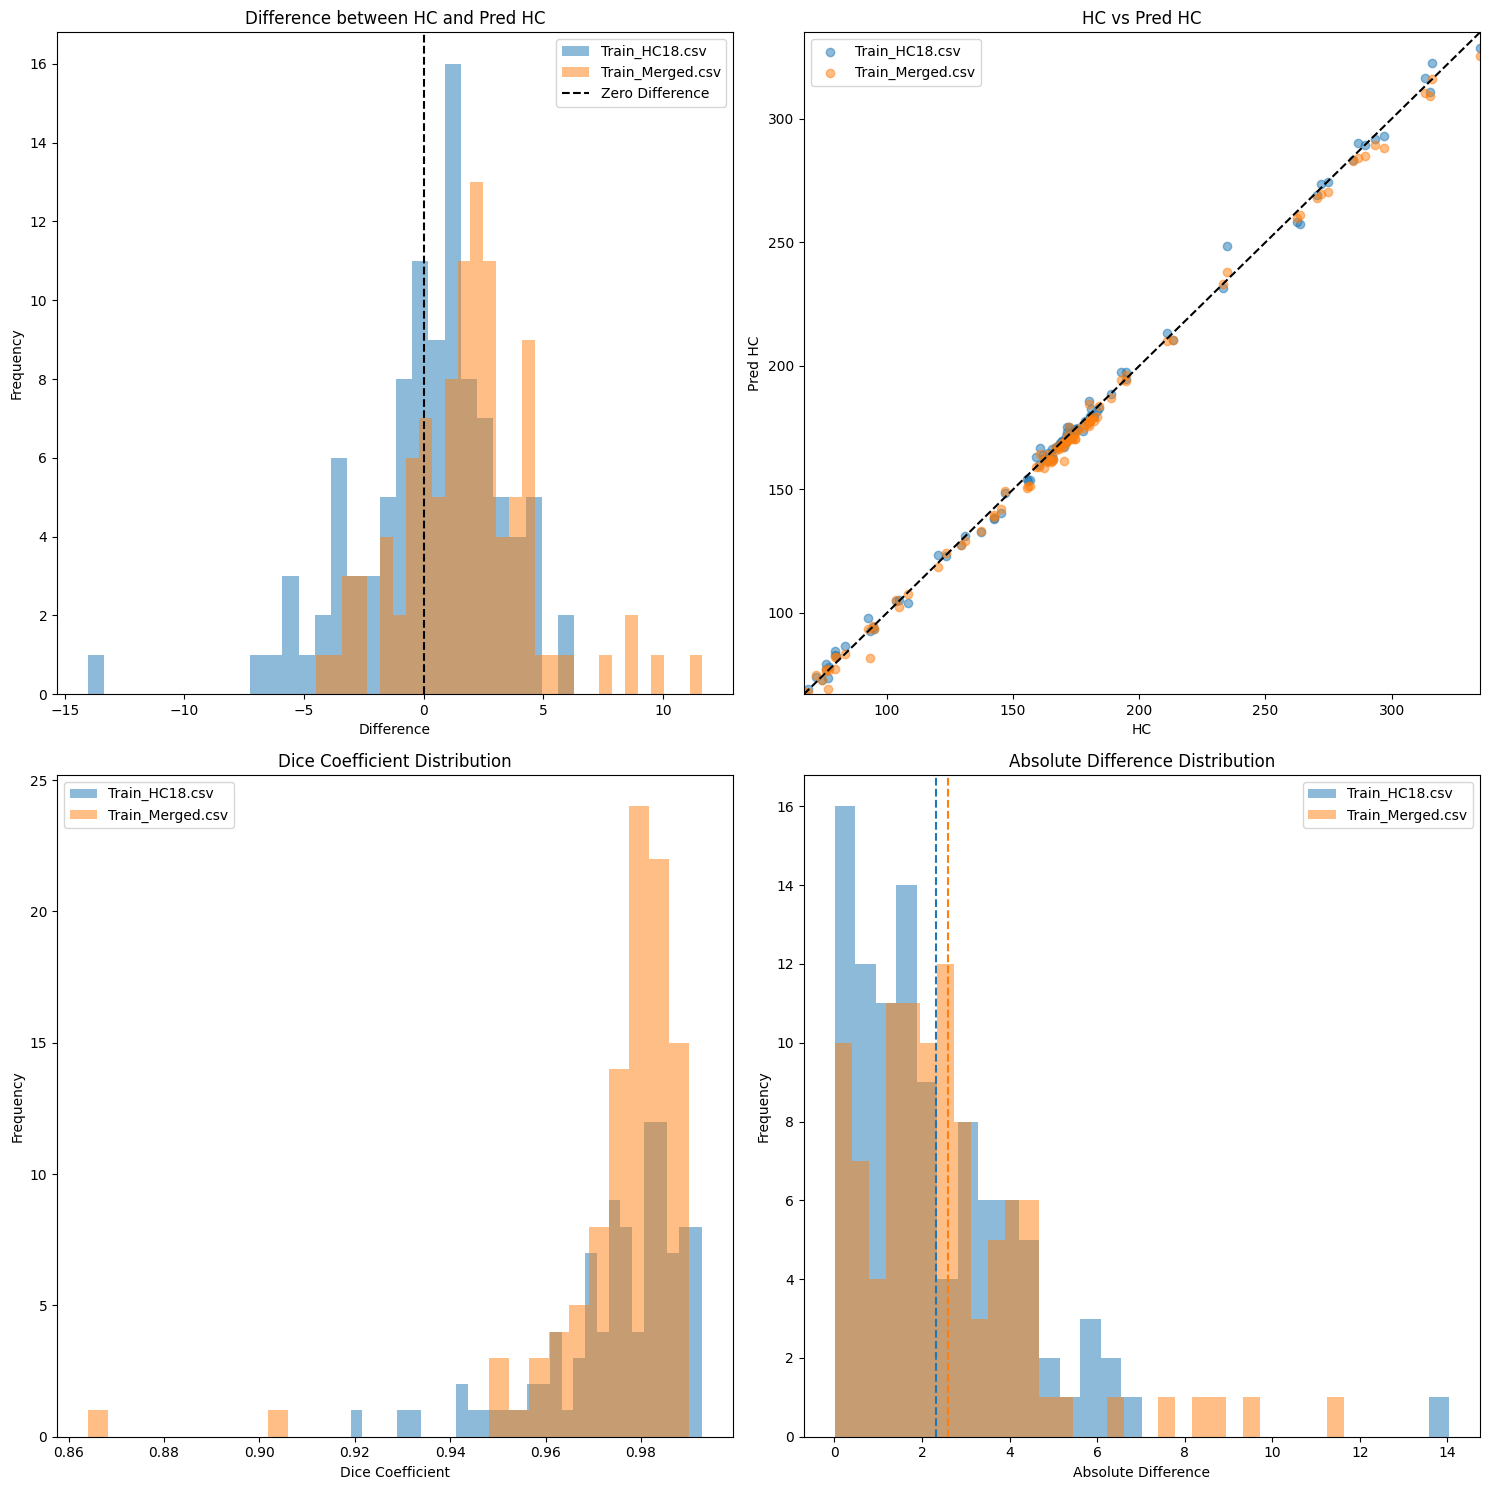

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import pearsonr

# List of paths instead of a single path
paths = ["../Fetal/HC18/Train_HC18.csv", "../Fetal/HC18/Train_Merged.csv"]  # Example paths
validation_images_path = "../Dataset/HC18/Landmarks_3_10/test.txt"

# Read validation images
validation_images = [line.strip() for line in open(validation_images_path).readlines()]

# Process each path
dfs = []
model_names = []
correlations = []
p_values = []

for path in paths:
    # Extract model name from path
    model_name = path.split('/')[-1]  # Model name from directory
    model_names.append(model_name)
    
    # Read and process data
    df = pd.read_csv(path)
    df = df[df['filename'].isin(validation_images)]
    df['Difference'] = df['HC'] - df['Pred HC']
    df['Absolute Difference'] = df['Difference'].abs()
    dfs.append(df)
    
    # Calculate Pearson correlation
    corr, p_val = pearsonr(df['HC'], df['Pred HC'])
    correlations.append(corr)
    p_values.append(p_val)

# Create figure
plt.figure(figsize=(15, 15))

# Colors for different models
colors = plt.cm.tab10.colors[:len(dfs)]

# Plot 1: Absolute Difference Histograms
plt.subplot(2, 2, 1)
for df, model_name, color in zip(dfs, model_names, colors):
    plt.hist(df['Difference'], bins=30, alpha=0.5, label=model_name, color=color)
plt.axvline(x=0, color='black', linestyle='--', label='Zero Difference')
plt.title("Difference between HC and Pred HC")
plt.xlabel("Difference")
plt.ylabel("Frequency")
plt.legend()

# Plot 2: HC vs Pred HC Scatter
plt.subplot(2, 2, 2)
for df, model_name, color in zip(dfs, model_names, colors):
    plt.scatter(df['HC'], df['Pred HC'], alpha=0.5, label=model_name, color=color)

# Find global min and max for consistent axes
all_hc = pd.concat([df['HC'] for df in dfs])
min_val, max_val = all_hc.min(), all_hc.max()

plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.title("HC vs Pred HC")
plt.xlabel("HC")
plt.ylabel("Pred HC")
plt.legend()

# Plot 3: Dice Coefficient Distribution
plt.subplot(2, 2, 3)
for df, model_name, color in zip(dfs, model_names, colors):
    plt.hist(df['dc'], bins=30, alpha=0.5, label=model_name, color=color)
plt.title("Dice Coefficient Distribution")
plt.xlabel("Dice Coefficient")
plt.ylabel("Frequency")
plt.legend()

# Plot 4: Hausdorff Distance Distribution
plt.subplot(2, 2, 4)
for df, model_name, color in zip(dfs, model_names, colors):
    plt.hist(df['Absolute Difference'], bins=30, alpha=0.5, label=model_name, color=color)
plt.title("Absolute Difference Distribution")
plt.xlabel("Absolute Difference")
plt.ylabel("Frequency")
plt.legend()
# draw mean for both in a axvline
for df, model_name, color in zip(dfs, model_names, colors):
    mean_diff = df['Absolute Difference'].mean()
    plt.axvline(x=mean_diff, color=color, linestyle='--', label=f"{model_name} Mean")
plt.tight_layout()

# Create correlation summary table
summary = pd.DataFrame({
    'Model': model_names,
    'Pearson Correlation': [f"{corr:.4f}" for corr in correlations],
    'P-value': [f"{p:.4f}" for p in p_values]
})

# Display the correlation table in Jupyter
summary